# Background harmonic viscosity
Create a background harmonic viscosity for the tx2_3 grid

In [1]:
%matplotlib inline

In [2]:
import xarray as xr
import numpy as np
import datetime
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [3]:
today = datetime.date.today().strftime("%y%m%d")
print(today)

260306


In [4]:
fname = '../mesh/tx2_3v3_grid.nc'
grd = xr.open_dataset(fname)
grd

<xarray.Dataset> Size: 42MB
Dimensions:  (ny: 480, nx: 540, nxp: 541, nyp: 481)
Dimensions without coordinates: ny, nx, nxp, nyp
Data variables: (12/20)
    tlon     (ny, nx) float64 2MB ...
    tlat     (ny, nx) float64 2MB ...
    ulon     (ny, nxp) float64 2MB ...
    ulat     (ny, nxp) float64 2MB ...
    vlon     (nyp, nx) float64 2MB ...
    vlat     (nyp, nx) float64 2MB ...
    ...       ...
    tarea    (ny, nx) float64 2MB ...
    tmask    (ny, nx) float64 2MB ...
    angle    (ny, nx) float64 2MB ...
    depth    (ny, nx) float64 2MB ...
    ar       (ny, nx) float64 2MB ...
    egs      (ny, nx) float64 2MB ...
Attributes:
    Description:  CESM MOM6 2/3 degree grid
    Author:       Frank, Fred, Gustavo (gmarques@ucar.edu)
    Created:      2026-03-05T14:49:28.971877
    type:         Glogal 2/3 degree grid file

In [5]:
depth = grd.depth
lath = grd.tlat
dims = depth.dims

In [6]:
# Build mask: 1 over land, 0 over ocean
mask = xr.where(depth > 0.0, 0, 1).astype(float).rename('mask')

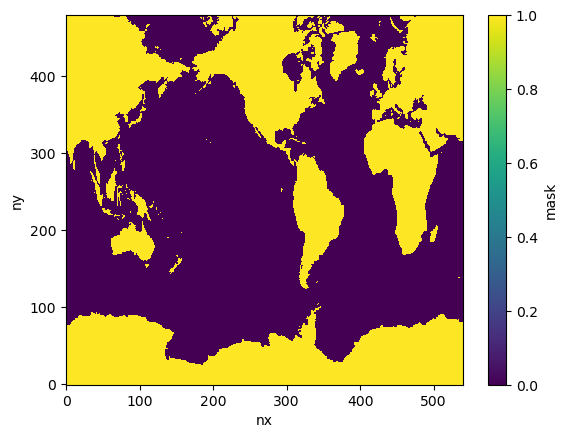

In [7]:
mask.plot()

In [8]:
# Taper so the mask smoothly goes to zero within 15° of the equator
mask[259:280,78] = 1.0
fy = (1 - np.minimum(np.abs(lath) / 15, 1) ** 2) ** 2
mask = fy * mask

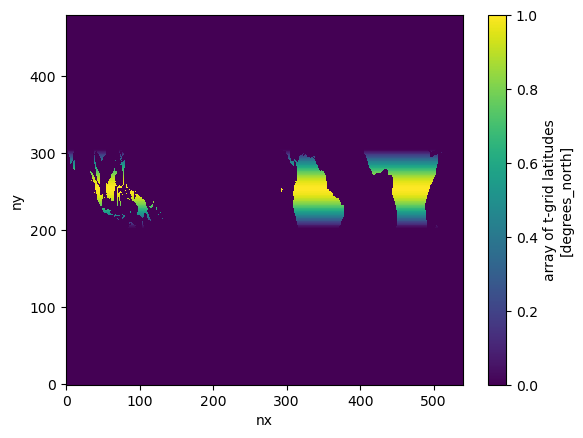

In [9]:
mask.plot()

In [10]:
# Propagate mask values into coastal ocean cells for smooth results.
# Land cells are pinned to their mask value; ocean cells are free to
# receive blended values from neighbors. 1 pass in lonh, 3 passes in lath, 40 times.
KH = mask.copy()
for i in range(40):
    KH = np.where(mask>0, mask, KH)
    KH = (1/4) * (2*KH + np.roll(KH,1,axis=1) + np.roll(KH,-1,axis=1))
    KH = np.where(mask>0, mask, KH)
    KH = (1/4) * (2*KH + np.roll(KH,1,axis=0) + np.roll(KH,-1,axis=0))
    KH = np.where(mask>0, mask, KH)
    KH = (1/4) * (2*KH + np.roll(KH,1,axis=0) + np.roll(KH,-1,axis=0))
    KH = np.where(mask>0, mask, KH)
    KH = (1/4) * (2*KH + np.roll(KH,1,axis=0) + np.roll(KH,-1,axis=0))

KH = np.where(mask>0, mask, KH)
KH[:,:25] = 0.
KH[:,-25:] = 0.
# Apply final masking and scaling
KH = xr.where(depth > 0.0, KH, np.nan) * 9000.0

In [11]:
ds_out = KH.rename("KH").to_dataset()
ds_out['KH'].attrs = {"units": "m^2 s^-1", "long_name": "Background harmonic viscosity"}

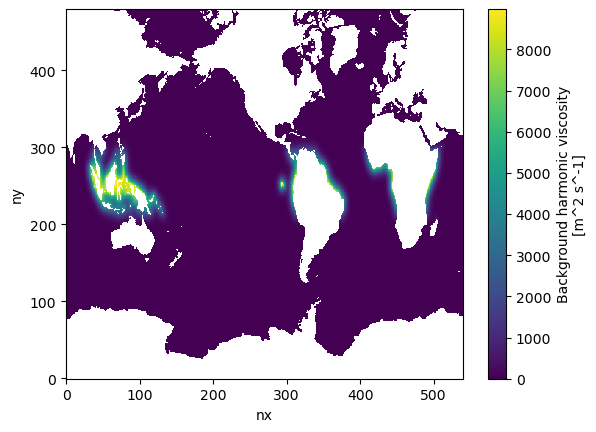

In [12]:
ds_out.KH.plot.pcolormesh()

In [13]:
# Save netcdf file

ds_out.attrs['Title']  = '2D background harmonic viscosity field for tx2_3v3'
ds_out.attrs['Author'] = 'Ian Grooms (ian.grooms@colorado.edu) & Gustavo Marques (gmarques@ucar.edu)'
ds_out.attrs['url'] = 'https://github.com/NCAR/tx2_3/background_viscosity'
ds_out.attrs["Date_created"] = today

fname = 'KH_BG_2D_tx2_3v3_{}.nc'.format(today)
ds_out.to_netcdf(fname, format="NETCDF3_64BIT")